# 03 - TCN avec Transfer Learning (Pre-entraînement + Fine-tuning)

## Stratégie en deux phases

### Phase 1 - Pre-entraînement auto-supervisé (inspiré de SignBERT)
- **Masked Temporal Modeling** : masquage de fenêtres temporelles de la séquence de keypoints
- Le modèle apprend à reconstruire les frames masquées (pas besoin de labels)
- Utilisable sur TOUT le dataset car non-supervisé

### Phase 2 - Fine-tuning supervisé (style ULMFiT / ST-GCN)
- Warm-up : backbone gelé, entraîner seulement la tête de classification
- Fine-tuning : dégel complet avec LR différentiels (backbone LR << head LR)

### Améliorations anti-surapprentissage vs `02_tcn_training`
- Label smoothing (0.1)
- Mixup augmentation
- Dropout annealing (0.5 -> 0.3)
- Weight decay plus fort (5e-3)
- Attention pooling temporel (vs avg pooling)
- 6 blocs TCN, kernel_size=5, Stochastic Depth (DropPath)


In [2]:
import numpy as np
import pandas as pd
import json
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from pathlib import Path
from tqdm.notebook import tqdm

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')

DATASET_ROOT = Path('../dataset/LSFB_ISOL_MINI')
POSES_ROOT   = DATASET_ROOT / 'poses'
METADATA_DIR = DATASET_ROOT / 'metadata'
AUG_ROOT     = DATASET_ROOT / 'augmented_tcn'

import sys
sys.path.insert(0, str(Path('../..').resolve()))
from src.signs import SIGNS_TARGET, SIGN_TO_IDX, IDX_TO_SIGN, NUM_CLASSES

TARGET_T      = 32
HIDDEN        = 256      # Plus large que 128 dans 02
DROPOUT_INIT  = 0.5      # Dropout fort au debut (anti-surapprentissage)
DROPOUT_FINAL = 0.3      # Dropout final apres annealing
WEIGHT_DECAY  = 5e-3
LABEL_SMOOTH  = 0.1
MASK_RATIO    = 0.3

print(f'Classes: {NUM_CLASSES}, Target T: {TARGET_T}')
print(f'Hidden: {HIDDEN}, Dropout: {DROPOUT_INIT}→{DROPOUT_FINAL}')

Using device: cuda
Classes: 20, Target T: 32
Hidden: 256, Dropout: 0.5→0.3


In [4]:
instances  = pd.read_csv(DATASET_ROOT / 'instances.csv')
pose_files = list((POSES_ROOT / 'pose').glob('*.npy'))
available  = {f.stem for f in pose_files}

# ── Dataset complet pour le pre-entraînement (TOUS les signes disponibles) ──
df_all = instances[instances['id'].isin(available)].copy()
lengths_all = {f.stem: np.load(f).shape[0] for f in pose_files}
df_all['T'] = df_all['id'].map(lengths_all)
df_all = df_all[df_all['T'] > 0].reset_index(drop=True)
df_pretrain_all = df_all  # aucun filtre de label : le pretrainer n'a pas besoin de labels

# ── Dataset filtre sur les signes cibles (fine-tuning / test) ─────────────
df = instances[instances['id'].isin(available)].copy()
df['label'] = df['sign'].map(SIGN_TO_IDX)
df = df[df['label'].notna()].copy()
df['label'] = df['label'].astype(int)

lengths = {f.stem: np.load(f).shape[0] for f in pose_files if f.stem in set(df['id'])}
df['T']  = df['id'].map(lengths)
df = df[df['T'] > 0].reset_index(drop=True)

with open(METADATA_DIR / 'splits' / 'train.json') as f:
    train_ids = set(json.load(f))
with open(METADATA_DIR / 'splits' / 'test.json') as f:
    test_ids = set(json.load(f))

df_train = df[df['id'].isin(train_ids)].reset_index(drop=True)
df_test  = df[df['id'].isin(test_ids)].reset_index(drop=True)

df_aug = pd.read_csv(AUG_ROOT / 'metadata.csv')
df_aug['label'] = df_aug['sign'].map(SIGN_TO_IDX)
df_aug = df_aug[df_aug['label'].notna()].copy()
df_aug['label'] = df_aug['label'].astype(int)

print(f'Pretrain ALL signes: {len(df_pretrain_all)} | Train cibles (raw): {len(df_train)} | Train (aug): {len(df_aug)} | Test: {len(df_test)}')
print(f'Signes uniques dans le pretrain: {df_pretrain_all["sign"].nunique()}')


Pretrain ALL signes: 120061 | Train cibles (raw): 3335 | Train (aug): 25820 | Test: 2720
Signes uniques dans le pretrain: 4631


In [5]:
def resample_sequence(arr: np.ndarray, target_T: int) -> np.ndarray:
    T = arr.shape[0]
    if T == 0:
        raise ValueError(f'resample_sequence: empty array {arr.shape}')
    if T == target_T:
        return arr
    idx = np.linspace(0, T - 1, target_T)
    lo  = np.floor(idx).astype(int).clip(0, T - 1)
    hi  = np.ceil(idx).astype(int).clip(0, T - 1)
    a   = (idx - lo)[:, None, None]
    return ((1 - a) * arr[lo] + a * arr[hi]).astype(np.float32)


def load_coords(instance_id: str, target_T: int = TARGET_T) -> np.ndarray:
    """Renvoie (225, T) float32, channel-first pour Conv1d."""
    body  = np.load(POSES_ROOT / 'pose'       / f'{instance_id}.npy').astype(np.float32)
    lhand = np.load(POSES_ROOT / 'left_hand'  / f'{instance_id}.npy').astype(np.float32)
    rhand = np.load(POSES_ROOT / 'right_hand' / f'{instance_id}.npy').astype(np.float32)
    body  = resample_sequence(body,  target_T)
    lhand = resample_sequence(lhand, target_T)
    rhand = resample_sequence(rhand, target_T)
    coords = np.concatenate([
        body.reshape(target_T, -1),
        lhand.reshape(target_T, -1),
        rhand.reshape(target_T, -1),
    ], axis=1)
    return coords.T  # (225, T)


class CoordDataset(Dataset):
    def __init__(self, df: pd.DataFrame, npy_root=None, target_T: int = TARGET_T):
        self.df       = df.reset_index(drop=True)
        self.npy_root = npy_root
        self.target_T = target_T

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        if self.npy_root is not None:
            coords = np.load(self.npy_root / f"{row['id']}.npy").astype(np.float32)
        else:
            coords = load_coords(row['id'], self.target_T)
        label = row['label'] if 'label' in row else 0
        return torch.from_numpy(coords), torch.tensor(label, dtype=torch.long)


# ── Split pretrain : 90 % train / 10 % val (stratifié par signe si dispo) ──
from sklearn.model_selection import train_test_split
_idx_all = list(range(len(df_pretrain_all)))
_idx_tr, _idx_val = train_test_split(_idx_all, test_size=0.10, random_state=42)
df_pretrain_tr  = df_pretrain_all.iloc[_idx_tr].reset_index(drop=True)
df_pretrain_val = df_pretrain_all.iloc[_idx_val].reset_index(drop=True)

pretrain_tr_dataset  = CoordDataset(df_pretrain_tr,  npy_root=None)  # TOUS les signes
pretrain_val_dataset = CoordDataset(df_pretrain_val, npy_root=None)
finetune_dataset     = CoordDataset(df_aug,   npy_root=AUG_ROOT / 'npy')
test_dataset         = CoordDataset(df_test,  npy_root=None)

pretrain_loader     = DataLoader(pretrain_tr_dataset,  batch_size=32, shuffle=True,  num_workers=0)
pretrain_val_loader = DataLoader(pretrain_val_dataset, batch_size=32, shuffle=False, num_workers=0)
finetune_loader     = DataLoader(finetune_dataset, batch_size=16, shuffle=True,  num_workers=0)
test_loader         = DataLoader(test_dataset,     batch_size=16, shuffle=False, num_workers=0)

xb, yb = next(iter(finetune_loader))
print(f'Batch finetune: X={xb.shape}, y={yb.shape}')
print(f'Pretrain train: {len(pretrain_tr_dataset)} | Pretrain val: {len(pretrain_val_dataset)}')
print(f'Finetune: {len(finetune_dataset)} | Test: {len(test_dataset)}')

Batch finetune: X=torch.Size([16, 225, 32]), y=torch.Size([16])
Pretrain train: 108054 | Pretrain val: 12007
Finetune: 25820 | Test: 2720


In [6]:
class TemporalBlock(nn.Module):
    """
    Bloc TCN résiduel amélioré vs 02 :
    - kernel_size=5 (vs 3) : contexte local plus large
    - Stochastic Depth : regularisation contre le surapprentissage
    """
    def __init__(self, in_channels, out_channels, kernel_size=5,
                 dilation=1, dropout=0.3, drop_path=0.1):
        super().__init__()
        padding = (kernel_size - 1) * dilation // 2
        self.conv1 = nn.Conv1d(in_channels,  out_channels, kernel_size,
                               padding=padding, dilation=dilation)
        self.bn1   = nn.BatchNorm1d(out_channels)
        self.conv2 = nn.Conv1d(out_channels, out_channels, kernel_size,
                               padding=padding, dilation=dilation)
        self.bn2   = nn.BatchNorm1d(out_channels)
        self.relu           = nn.ReLU(inplace=True)
        self.dropout        = nn.Dropout(dropout)
        self.drop_path_prob = drop_path
        self.downsample = (
            nn.Conv1d(in_channels, out_channels, 1)
            if in_channels != out_channels else None
        )

    def _drop_path(self, x):
        """Stochastic Depth : annule aléatoirement le résidu en training."""
        if not self.training or self.drop_path_prob == 0.0:
            return x
        keep = 1.0 - self.drop_path_prob
        mask = (torch.rand(x.shape[0], 1, 1, device=x.device) < keep).float() / keep
        return x * mask

    def forward(self, x):
        residual = x if self.downsample is None else self.downsample(x)
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.dropout(out)
        out = self.relu(self.bn2(self.conv2(out)))
        out = self.dropout(out)
        return self.relu(self._drop_path(out) + residual)


class AttentionPooling(nn.Module):
    """
    Pooling par attention temporelle (vs avg pooling dans 02).
    Apprend quelles frames sont les plus informatives pour la classification.
    Inspiré de l'attention de SignBERT sur les keypoints saillants.
    """
    def __init__(self, hidden):
        super().__init__()
        self.attn = nn.Sequential(
            nn.Linear(hidden, hidden // 4),
            nn.Tanh(),
            nn.Linear(hidden // 4, 1, bias=False),
        )

    def forward(self, x):
        x_t     = x.permute(0, 2, 1)                    # (B, T, C)
        weights = torch.softmax(self.attn(x_t), dim=1)  # (B, T, 1)
        return (x_t * weights).sum(dim=1)               # (B, C)


class TCNEncoder(nn.Module):
    """
    Encodeur TCN pre-entraînable.
    Améliorations vs 02 :
    - 6 blocs (vs 4) avec dilatations [1,2,4,8,16,32]
    - kernel_size=5 (vs 3)
    - hidden=256 (vs 128)
    - Stochastic Depth
    - Attention Pooling
    """
    def __init__(self, in_channels=225, hidden=256, dropout=0.3):
        super().__init__()
        self.input_proj = nn.Sequential(
            nn.Conv1d(in_channels, hidden, kernel_size=1),
            nn.BatchNorm1d(hidden),
            nn.ReLU(inplace=True),
        )
        drop_paths = [0.05, 0.05, 0.1, 0.1, 0.15, 0.15]
        dilations  = [1, 2, 4, 8, 16, 32]
        self.blocks = nn.Sequential(*[
            TemporalBlock(hidden, hidden, kernel_size=5,
                          dilation=d, dropout=dropout, drop_path=dp)
            for d, dp in zip(dilations, drop_paths)
        ])
        self.pool = AttentionPooling(hidden)

    def forward(self, x):
        x = self.input_proj(x)   # (B, hidden, T)
        x = self.blocks(x)       # (B, hidden, T)
        return self.pool(x)      # (B, hidden)

    def set_dropout(self, p):
        """Modifie le dropout de tous les blocs (pour l'annealing)."""
        for block in self.blocks:
            block.dropout.p = p


_enc = TCNEncoder(hidden=HIDDEN).to(DEVICE)
_out = _enc(torch.randn(4, 225, TARGET_T).to(DEVICE))
assert _out.shape == (4, HIDDEN)
print(f'Encodeur OK : {_out.shape}')
print(f'Parametres encodeur: {sum(p.numel() for p in _enc.parameters()):,}')

Encodeur OK : torch.Size([4, 256])
Parametres encodeur: 4,016,256


In [7]:
class MaskedTCNPretrainer(nn.Module):
    """
    Pre-entraîneur par Masked Temporal Modeling (inspiré de SignBERT).

    Tache auto-supervisée :
    1. Projeter (225, T) → (hidden, T) via input_proj
    2. Masquer un bloc contigu de frames (MASK_RATIO)
    3. Passer dans le backbone TCN
    4. Reconstruire les features originaux aux positions masquées

    Avantage : force le backbone à apprendre des dépendances
    temporelles globales sans nécessiter de labels.
    """
    def __init__(self, encoder, hidden=256, mask_ratio=0.3):
        super().__init__()
        self.encoder    = encoder
        self.mask_ratio = mask_ratio
        # Token de masque appris (comme BERT)
        self.mask_token = nn.Parameter(torch.zeros(1, hidden, 1))
        nn.init.trunc_normal_(self.mask_token, std=0.02)
        # Décodeur léger pour la reconstruction
        self.decoder = nn.Sequential(
            nn.Conv1d(hidden, hidden, kernel_size=3, padding=1),
            nn.GELU(),
            nn.Conv1d(hidden, hidden, kernel_size=1),
        )

    def _mask(self, x_proj):
        """Masque un bloc contigu de frames dans chaque séquence du batch."""
        B, C, T = x_proj.shape
        num_mask = max(1, int(T * self.mask_ratio))
        mask = torch.zeros(B, T, dtype=torch.bool, device=x_proj.device)
        for b in range(B):
            start = torch.randint(0, T - num_mask + 1, (1,)).item()
            mask[b, start:start + num_mask] = True
        x_masked = x_proj.clone()
        token    = self.mask_token.expand(B, C, T)
        exp_mask = mask.unsqueeze(1).expand_as(x_proj)
        x_masked[exp_mask] = token[exp_mask]
        return x_masked, mask

    def forward(self, x):
        x_proj = self.encoder.input_proj(x)     # (B, hidden, T)
        target = x_proj.detach()
        x_masked, mask = self._mask(x_proj)
        x_enc = self.encoder.blocks(x_masked)   # (B, hidden, T)
        pred  = self.decoder(x_enc)             # (B, hidden, T)
        exp_mask = mask.unsqueeze(1).expand_as(pred)
        loss = F.mse_loss(pred[exp_mask], target[exp_mask])
        return loss, pred, target, mask


encoder    = TCNEncoder(in_channels=225, hidden=HIDDEN, dropout=DROPOUT_INIT).to(DEVICE)
pretrainer = MaskedTCNPretrainer(encoder, hidden=HIDDEN, mask_ratio=MASK_RATIO).to(DEVICE)

_loss, _, _, _ = pretrainer(torch.randn(4, 225, TARGET_T).to(DEVICE))
print(f'Pretrainer OK — loss test: {_loss.item():.4f}')
print(f'Parametres total: {sum(p.numel() for p in pretrainer.parameters()):,}')

Pretrainer OK — loss test: 1.1899
Parametres total: 4,279,168


Pre-entrainement : 108054 train / 12007 val
Epochs max: 10 | Patience: 3 | Min delta: 1e-05
Tache : Masked Temporal Modeling



Pre-entrainement:   0%|          | 0/10 [00:00<?, ?epoch/s]

  Epoch 001:   0%|          | 0/3377 [00:00<?, ?batch/s]

  Epoch 001/10 | train=0.0959 | val=0.0801 | lr=9.8e-04


  Epoch 002:   0%|          | 0/3377 [00:00<?, ?batch/s]

...

  Epoch 007:   0%|          | 0/3377 [00:00<?, ?batch/s]

  Epoch 008:   0%|          | 0/3377 [00:00<?, ?batch/s]

  Epoch 009:   0%|          | 0/3377 [00:00<?, ?batch/s]

  Epoch 010:   0%|          | 0/3377 [00:00<?, ?batch/s]

  Epoch 010/10 | train=0.0234 | val=0.0171 | lr=1.0e-05
Encodeur best (10 epochs) sauvegarde -> ../../src/models/tcn_pretrained_encoder.pth
Val MSE finale (best) : 0.0171


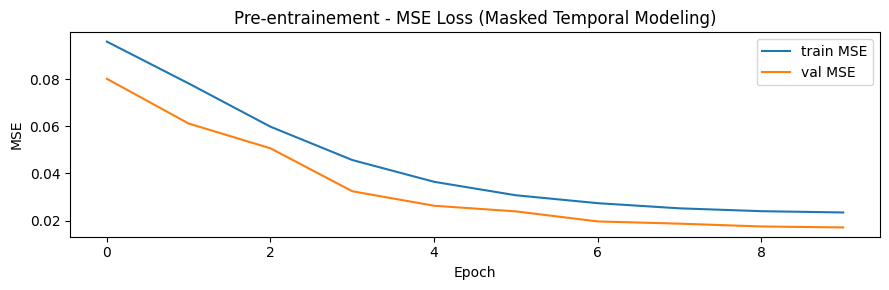

In [9]:
PRETRAIN_EPOCHS   = 10
PRETRAIN_LR       = 1e-3
PRETRAIN_PATIENCE  = 3
PRETRAIN_MIN_DELTA = 1e-5
BEST_ENCODER_PATH  = "../../src/models/tcn_pretrained_encoder.pth"

pretrain_optim = optim.AdamW(
    pretrainer.parameters(), lr=PRETRAIN_LR, weight_decay=WEIGHT_DECAY
)
pretrain_sched = optim.lr_scheduler.CosineAnnealingLR(
    pretrain_optim, T_max=PRETRAIN_EPOCHS, eta_min=1e-5
)

pretrain_losses, pretrain_val_losses = [], []
best_val_mse      = float("inf")
epochs_no_improve = 0
stopped_epoch     = PRETRAIN_EPOCHS

print(f"Pre-entrainement : {len(pretrain_tr_dataset)} train / {len(pretrain_val_dataset)} val")
print(f"Epochs max: {PRETRAIN_EPOCHS} | Patience: {PRETRAIN_PATIENCE} | Min delta: {PRETRAIN_MIN_DELTA}")
print("Tache : Masked Temporal Modeling")
print()

os.makedirs("../../src/models", exist_ok=True)

epoch_bar = tqdm(range(1, PRETRAIN_EPOCHS + 1), desc="Pre-entrainement", unit="epoch")
for epoch in epoch_bar:
    pretrainer.train()
    epoch_loss, n = 0.0, 0
    batch_bar = tqdm(pretrain_loader, desc=f"  Epoch {epoch:03d}", leave=False, unit="batch")
    for X_batch, _ in batch_bar:
        X_batch = X_batch.to(DEVICE)
        pretrain_optim.zero_grad()
        loss, _, _, _ = pretrainer(X_batch)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(pretrainer.parameters(), max_norm=1.0)
        pretrain_optim.step()
        epoch_loss += loss.item()
        n += 1
        batch_bar.set_postfix(mse=f"{loss.item():.4f}")
    train_mse = epoch_loss / n
    pretrain_losses.append(train_mse)

    pretrainer.eval()
    val_loss, val_n = 0.0, 0
    with torch.no_grad():
        for X_batch, _ in pretrain_val_loader:
            X_batch = X_batch.to(DEVICE)
            loss, _, _, _ = pretrainer(X_batch)
            val_loss += loss.item()
            val_n    += 1
    val_mse = val_loss / val_n
    pretrain_val_losses.append(val_mse)

    pretrain_sched.step()
    lr = pretrain_optim.param_groups[0]["lr"]
    epoch_bar.set_postfix(train=f"{train_mse:.4f}", val=f"{val_mse:.4f}", lr=f"{lr:.1e}")

    if epoch % 5 == 0 or epoch == 1:
        print(f"  Epoch {epoch:03d}/{PRETRAIN_EPOCHS} | train={train_mse:.4f} | val={val_mse:.4f} | lr={lr:.1e}")

    if val_mse < best_val_mse - PRETRAIN_MIN_DELTA:
        best_val_mse      = val_mse
        epochs_no_improve = 0
        torch.save(encoder.state_dict(), BEST_ENCODER_PATH)
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= PRETRAIN_PATIENCE:
            stopped_epoch = epoch
            print(f"Early stopping epoch {epoch} (patience={PRETRAIN_PATIENCE})")
            print(f"Meilleure val MSE : {best_val_mse:.4f}")
            break

encoder.load_state_dict(torch.load(BEST_ENCODER_PATH, map_location=DEVICE))
print(f"Encodeur best ({stopped_epoch} epochs) sauvegarde -> {BEST_ENCODER_PATH}")
print(f"Val MSE finale (best) : {best_val_mse:.4f}")

plt.figure(figsize=(9, 3))
plt.plot(pretrain_losses,     label="train MSE", linewidth=1.5)
plt.plot(pretrain_val_losses, label="val MSE",   linewidth=1.5)
if stopped_epoch < PRETRAIN_EPOCHS:
    plt.axvline(stopped_epoch - 1, color="red", linestyle="--", label=f"early stop (ep {stopped_epoch})")
plt.title("Pre-entrainement - MSE Loss (Masked Temporal Modeling)")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.legend()
plt.tight_layout()
plt.show()

In [8]:
class LabelSmoothingCrossEntropy(nn.Module):
    """CrossEntropy avec label smoothing pour réduire le surapprentissage."""
    def __init__(self, smoothing=0.1, weight=None):
        super().__init__()
        self.smoothing = smoothing
        self.weight    = weight

    def forward(self, logits, targets):
        n_classes = logits.size(-1)
        log_probs = F.log_softmax(logits, dim=-1)
        smooth_targets = torch.full_like(log_probs, self.smoothing / (n_classes - 1))
        smooth_targets.scatter_(-1, targets.unsqueeze(-1), 1.0 - self.smoothing)
        if self.weight is not None:
            w    = self.weight[targets]
            loss = -(smooth_targets * log_probs).sum(-1) * w
            return loss.sum() / w.sum()
        return -(smooth_targets * log_probs).sum(-1).mean()


def mixup_batch(x, y, alpha=0.2):
    """Mixup data augmentation (Zhang et al. 2017)."""
    if alpha <= 0.0:
        return x, y, y, 1.0
    lam = float(np.random.beta(alpha, alpha))
    idx = torch.randperm(x.size(0), device=x.device)
    return lam * x + (1 - lam) * x[idx], y, y[idx], lam


class TCNClassifier(nn.Module):
    """
    TCNEncoder pre-entraîné + tête de classification MLP.
    Supporte le gel/dégel du backbone pour le fine-tuning progressif.
    """
    def __init__(self, encoder, hidden=256, num_classes=20, dropout=0.5):
        super().__init__()
        self.encoder = encoder
        self.head = nn.Sequential(
            nn.LayerNorm(hidden),
            nn.Dropout(dropout),
            nn.Linear(hidden, hidden // 2),
            nn.GELU(),
            nn.Dropout(dropout / 2),
            nn.Linear(hidden // 2, num_classes),
        )

    def forward(self, x):
        return self.head(self.encoder(x))

    def freeze_encoder(self):
        for p in self.encoder.parameters():
            p.requires_grad_(False)
        print('Backbone gelé')

    def unfreeze_encoder(self):
        for p in self.encoder.parameters():
            p.requires_grad_(True)
        print('Backbone dégelé')


# Instanciation avec poids pre-entraînes
encoder_ft = TCNEncoder(in_channels=225, hidden=HIDDEN, dropout=DROPOUT_INIT).to(DEVICE)
encoder_ft.load_state_dict(
    torch.load('../../src/models/tcn_pretrained_encoder.pth', map_location=DEVICE)
)
model = TCNClassifier(encoder_ft, hidden=HIDDEN,
                      num_classes=NUM_CLASSES, dropout=DROPOUT_INIT).to(DEVICE)

_out = model(torch.randn(4, 225, TARGET_T).to(DEVICE))
assert _out.shape == (4, NUM_CLASSES)
print(f'TCNClassifier OK : {_out.shape}')
print(f'Parametres totaux: {sum(p.numel() for p in model.parameters()):,}')

counts     = np.bincount(df_aug['label'].values, minlength=NUM_CLASSES).astype(np.float32)
ce_weights = torch.tensor(1.0 / np.maximum(counts, 1.0), dtype=torch.float32).to(DEVICE)
ce_weights /= ce_weights.sum()
criterion  = LabelSmoothingCrossEntropy(smoothing=LABEL_SMOOTH, weight=ce_weights)
print('Critere : Label Smoothing CE + pondération de classe')

TCNClassifier OK : torch.Size([4, 20])
Parametres totaux: 4,052,244
Critere : Label Smoothing CE + pondération de classe


In [9]:
def train_one_epoch(model, loader, criterion, optimizer, device, mixup_alpha=0.2):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for X_batch, y_batch in loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        X_mix, y_a, y_b, lam = mixup_batch(X_batch, y_batch, mixup_alpha)
        optimizer.zero_grad()
        logits = model(X_mix)
        loss = lam * criterion(logits, y_a) + (1 - lam) * criterion(logits, y_b)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item() * len(y_batch)
        correct    += (logits.argmax(1) == y_batch).sum().item()
        total      += len(y_batch)
    return total_loss / total, correct / total


def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels = [], []
    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            logits = model(X_batch)
            loss   = criterion(logits, y_batch)
            total_loss += loss.item() * len(y_batch)
            preds       = logits.argmax(1)
            correct    += (preds == y_batch).sum().item()
            total      += len(y_batch)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y_batch.cpu().numpy())
    f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    return total_loss / total, correct / total, f1, np.array(all_preds), np.array(all_labels)


print('Fonctions train/evaluate définies.')

Fonctions train/evaluate définies.


In [10]:
# Etape 2a : Warm-up — tête seulement, backbone gelé
# Initialise la tête avant de dégeler pour ne pas perturber les
# représentations pre-entraînées (principe ULMFiT).

WARMUP_EPOCHS = 8
WARMUP_LR     = 1e-3

model.freeze_encoder()
optimizer_wu = optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=WARMUP_LR, weight_decay=WEIGHT_DECAY
)
sched_wu = optim.lr_scheduler.OneCycleLR(
    optimizer_wu, max_lr=WARMUP_LR,
    epochs=WARMUP_EPOCHS, steps_per_epoch=len(finetune_loader)
)

history = {k: [] for k in ['train_loss','train_acc','val_loss','val_acc','val_f1','phase']}
best_val_acc = 0.0
best_path    = '../../src/models/best_tcn_pretrained.pth'

print(f'Warm-up : {WARMUP_EPOCHS} epochs (backbone gelé)')
for epoch in range(1, WARMUP_EPOCHS + 1):
    tr_loss, tr_acc = train_one_epoch(model, finetune_loader, criterion,
                                       optimizer_wu, DEVICE, mixup_alpha=0.0)
    val_loss, val_acc, val_f1, _, _ = evaluate(model, test_loader, criterion, DEVICE)
    sched_wu.step()
    for k, v in zip(['train_loss','train_acc','val_loss','val_acc','val_f1'],
                    [tr_loss, tr_acc, val_loss, val_acc, val_f1]):
        history[k].append(v)
    history['phase'].append('warmup')
    print(f'  WU {epoch:02d}/{WARMUP_EPOCHS} | train {tr_acc:.3f} | val {val_acc:.3f} f1={val_f1:.3f}')
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), best_path)

print(f'\nMeilleur acc warm-up: {best_val_acc:.4f}')

Backbone gelé
Warm-up : 8 epochs (backbone gelé)
  WU 01/8 | train 0.109 | val 0.365 f1=0.051
  WU 02/8 | train 0.179 | val 0.364 f1=0.107
  WU 03/8 | train 0.223 | val 0.360 f1=0.130
  WU 04/8 | train 0.254 | val 0.348 f1=0.139
  WU 05/8 | train 0.271 | val 0.351 f1=0.151
  WU 06/8 | train 0.292 | val 0.344 f1=0.149
  WU 07/8 | train 0.303 | val 0.356 f1=0.170
  WU 08/8 | train 0.321 | val 0.356 f1=0.158

Meilleur acc warm-up: 0.3654


In [11]:
# Etape 2b : Fine-tuning complet avec LR différentiels
# LR backbone << LR tête (discriminative fine-tuning, style ULMFiT / ST-GCN)
# + Dropout annealing progressif de DROPOUT_INIT vers DROPOUT_FINAL

FT_EPOCHS   = 60
PATIENCE    = 15
LR_BACKBONE = 3e-5   # Tres faible : préserve les représentations pre-entraînées
LR_HEAD     = 3e-4   # Plus élevé pour la tête de classification
MIXUP_ALPHA = 0.2

model.unfreeze_encoder()
param_groups = [
    {'params': model.encoder.parameters(), 'lr': LR_BACKBONE},
    {'params': model.head.parameters(),    'lr': LR_HEAD},
]
optimizer_ft = optim.AdamW(param_groups, weight_decay=WEIGHT_DECAY)
scheduler_ft = optim.lr_scheduler.CosineAnnealingLR(
    optimizer_ft, T_max=FT_EPOCHS, eta_min=1e-6
)

epochs_no_improve = 0
print(f'Fine-tuning : {FT_EPOCHS} epochs | LR backbone={LR_BACKBONE:.0e}, head={LR_HEAD:.0e}\n')

for epoch in range(1, FT_EPOCHS + 1):
    # Dropout annealing
    frac = epoch / FT_EPOCHS
    current_dp = DROPOUT_INIT - frac * (DROPOUT_INIT - DROPOUT_FINAL)
    model.encoder.set_dropout(current_dp)

    tr_loss, tr_acc = train_one_epoch(model, finetune_loader, criterion,
                                       optimizer_ft, DEVICE, mixup_alpha=MIXUP_ALPHA)
    val_loss, val_acc, val_f1, _, _ = evaluate(model, test_loader, criterion, DEVICE)
    scheduler_ft.step()

    for k, v in zip(['train_loss','train_acc','val_loss','val_acc','val_f1'],
                    [tr_loss, tr_acc, val_loss, val_acc, val_f1]):
        history[k].append(v)
    history['phase'].append('finetune')

    lr_b = optimizer_ft.param_groups[0]['lr']
    print(f'FT {epoch:03d}/{FT_EPOCHS} | '
          f'train loss={tr_loss:.4f} acc={tr_acc:.3f} | '
          f'val loss={val_loss:.4f} acc={val_acc:.3f} f1={val_f1:.3f} | '
          f'dp={current_dp:.2f} lr_b={lr_b:.1e}')

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        epochs_no_improve = 0
        torch.save(model.state_dict(), best_path)
        print(f'  Meilleur modele (val_acc={val_acc:.4f})')
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= PATIENCE:
            print(f'Early stopping epoch {WARMUP_EPOCHS + epoch}')
            break

print(f'\nMeilleur val_acc global: {best_val_acc:.4f}')

Backbone dégelé
Fine-tuning : 60 epochs | LR backbone=3e-05, head=3e-04

FT 001/60 | train loss=2.3590 acc=0.234 | val loss=2.0784 acc=0.402 f1=0.202 | dp=0.50 lr_b=3.0e-05
  Meilleur modele (val_acc=0.4018)
FT 002/60 | train loss=2.1638 acc=0.277 | val loss=1.9731 acc=0.436 f1=0.229 | dp=0.49 lr_b=3.0e-05
  Meilleur modele (val_acc=0.4357)
FT 003/60 | train loss=2.0620 acc=0.295 | val loss=1.9091 acc=0.464 f1=0.255 | dp=0.49 lr_b=3.0e-05
  Meilleur modele (val_acc=0.4640)
FT 004/60 | train loss=1.9687 acc=0.319 | val loss=1.9168 acc=0.449 f1=0.257 | dp=0.49 lr_b=3.0e-05
FT 005/60 | train loss=1.9379 acc=0.332 | val loss=1.8782 acc=0.462 f1=0.260 | dp=0.48 lr_b=3.0e-05
FT 006/60 | train loss=1.8935 acc=0.339 | val loss=1.8462 acc=0.482 f1=0.268 | dp=0.48 lr_b=2.9e-05
  Meilleur modele (val_acc=0.4816)
FT 007/60 | train loss=1.8551 acc=0.344 | val loss=1.8207 acc=0.497 f1=0.283 | dp=0.48 lr_b=2.9e-05
  Meilleur modele (val_acc=0.4967)
FT 008/60 | train loss=1.8298 acc=0.364 | val loss=1

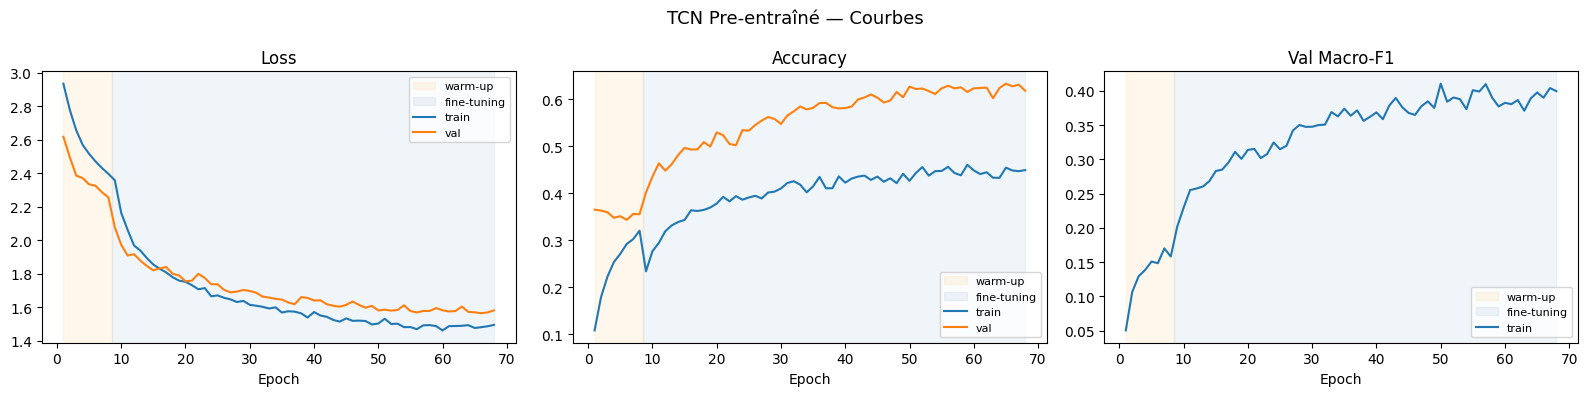

Gap moyen train-val (fine-tuning) : -0.1611  (faible surapprentissage)


In [12]:
phases   = history['phase']
n_warmup = phases.count('warmup')

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
configs = [
    ('train_loss', 'val_loss', 'Loss'),
    ('train_acc',  'val_acc',  'Accuracy'),
    ('val_f1',     None,       'Val Macro-F1'),
]
for ax, (key_tr, key_val, title) in zip(axes, configs):
    n      = len(history[key_tr])
    epochs = list(range(1, n + 1))
    ax.axvspan(1, n_warmup + 0.5, alpha=0.08, color='orange',    label='warm-up')
    ax.axvspan(n_warmup + 0.5, n, alpha=0.08, color='steelblue', label='fine-tuning')
    ax.plot(epochs, history[key_tr], label='train', linewidth=1.5)
    if key_val:
        ax.plot(epochs, history[key_val], label='val', linewidth=1.5)
    ax.set_title(title); ax.set_xlabel('Epoch'); ax.legend(fontsize=8)

plt.suptitle('TCN Pre-entraîné — Courbes', fontsize=13)
plt.tight_layout(); plt.show()

ft_gap = np.mean(
    np.array(history['train_acc'][n_warmup:]) - np.array(history['val_acc'][n_warmup:])
)
print(f'Gap moyen train-val (fine-tuning) : {ft_gap:.4f}  '
      f"({'faible surapprentissage' if ft_gap < 0.05 else 'surapprentissage détecté'})")

In [13]:
model.load_state_dict(torch.load(best_path, map_location=DEVICE))
_, test_acc, test_f1, preds, labels = evaluate(model, test_loader, criterion, DEVICE)

print(f'Test Accuracy : {test_acc:.4f}')
print(f'Test Macro-F1 : {test_f1:.4f}')
print()
print(classification_report(labels, preds, target_names=SIGNS_TARGET, zero_division=0))

print('\n' + '='*55)
print('  Comparaison vs baseline (02_tcn_training)')
print('='*55)
baseline_path = '../../src/models/tcn_medisign_final.pth'
if os.path.exists(baseline_path):
    payload = torch.load(baseline_path, map_location=DEVICE)
    meta  = payload.get('metadata', {})
    b_acc = meta.get('test_accuracy', 'N/A')
    b_f1  = meta.get('test_macro_f1', 'N/A')
    print(f'  Baseline     — Acc: {b_acc}  |  F1: {b_f1}')
    print(f'  Pre-entraîné — Acc: {test_acc:.4f}  |  F1: {test_f1:.4f}')
    if isinstance(b_acc, float):
        print(f'  Delta Acc: {test_acc-b_acc:+.4f}  |  Delta F1: {test_f1-b_f1:+.4f}')
print('='*55)

Test Accuracy : 0.6335
Test Macro-F1 : 0.3975

               precision    recall  f1-score   support

          OUI       0.71      0.82      0.76      1013
          NON       0.72      0.55      0.62       583
      APPELER       0.50      0.28      0.36       223
         VITE       0.55      0.41      0.47       116
       MANGER       0.45      0.43      0.44        92
   COMPRENDRE       0.64      0.72      0.68       260
        BOIRE       0.06      0.09      0.07        22
MALADE.VENTRE       0.36      0.59      0.44        17
        CHAUD       0.20      0.48      0.28        21
       DORMIR       0.43      0.51      0.47        37
     RESPIRER       0.50      0.67      0.57         3
       TOMBER       0.33      0.33      0.33        18
        FROID       0.11      0.18      0.14        22
       FAIBLE       0.00      0.00      0.00         0
     ENCEINTE       0.33      0.07      0.12        14
      HOPITAL       0.22      0.68      0.33        19
     SOUFFRIR    

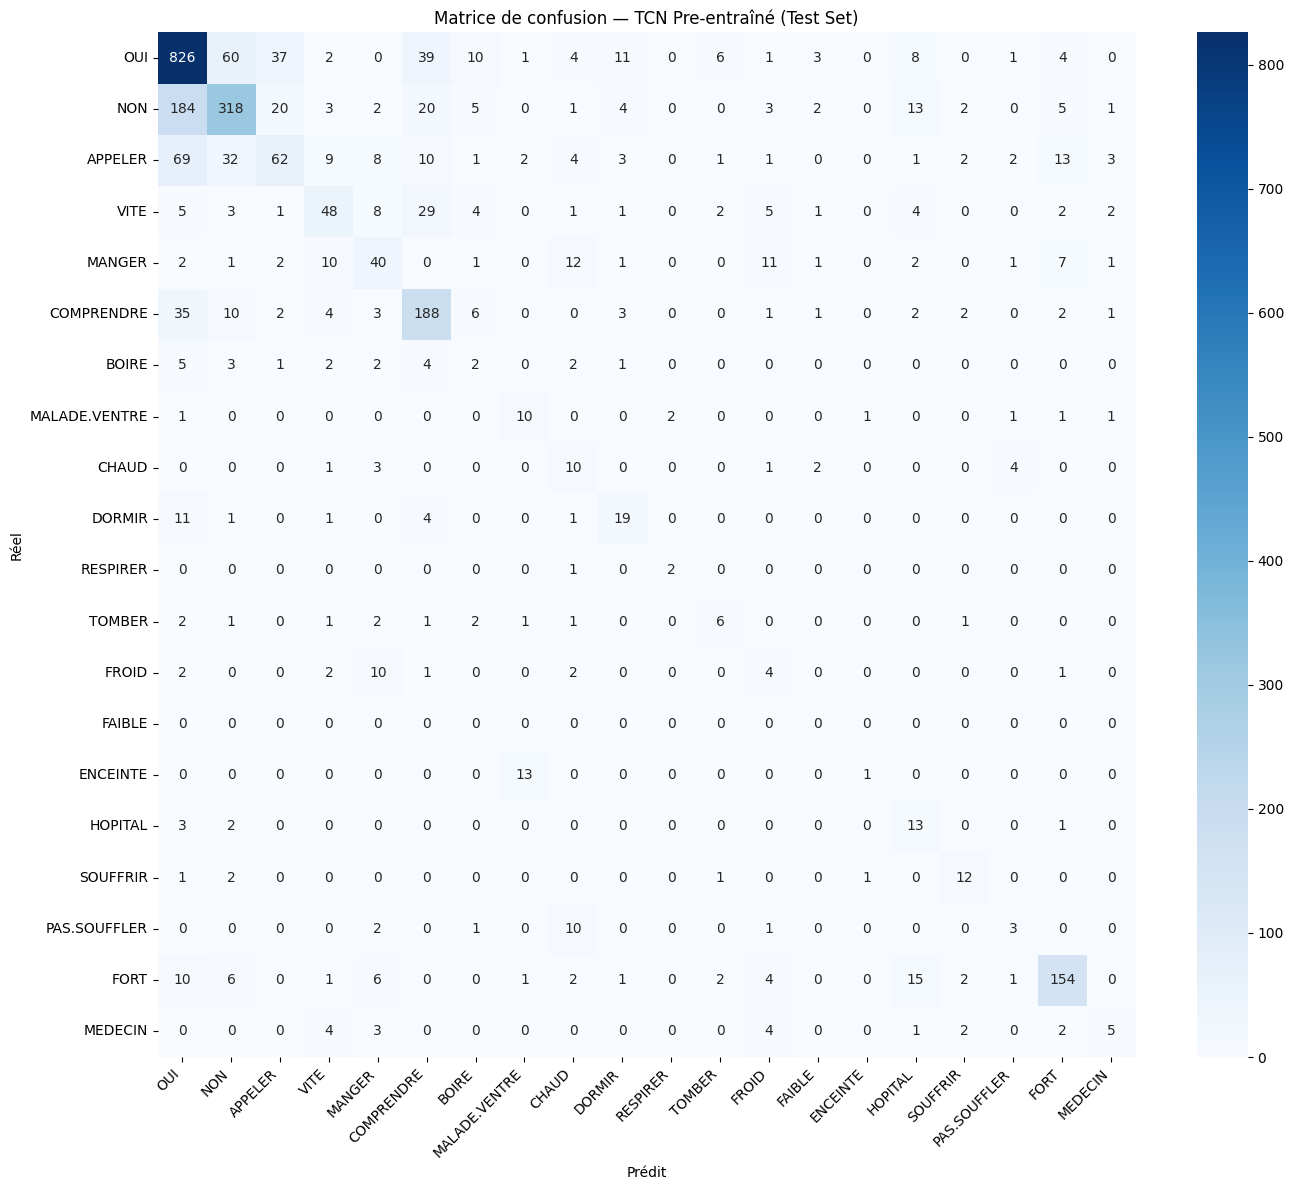

In [14]:
cm = confusion_matrix(labels, preds, labels=list(range(NUM_CLASSES)))
fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=SIGNS_TARGET, yticklabels=SIGNS_TARGET, ax=ax,
)
ax.set_xlabel('Prédit'); ax.set_ylabel('Réel')
ax.set_title('Matrice de confusion — TCN Pre-entraîné (Test Set)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout(); plt.show()

In [15]:
def save_model(model, path, metadata=None):
    os.makedirs(os.path.dirname(path), exist_ok=True)
    payload = {'state_dict': model.state_dict()}
    if metadata:
        payload['metadata'] = metadata
    torch.save(payload, path)
    print(f'Sauvegardé -> {path}')


save_model(model, '../../src/models/tcn_pretrained_final.pth', metadata={
    'test_accuracy':  round(float(test_acc), 4),
    'test_macro_f1':  round(float(test_f1), 4),
    'num_classes':    NUM_CLASSES,
    'signs':          SIGNS_TARGET,
    'input_shape':    [225, TARGET_T],
    'architecture':   'TCNEncoder(6 blocs, hidden=256, kernel=5, attn-pool) + MLP head',
    'pretrain':       f'Masked Temporal Modeling ({PRETRAIN_EPOCHS} epochs, mask={MASK_RATIO})',
    'finetune':       f'warmup={WARMUP_EPOCHS}ep + ft={FT_EPOCHS}ep, '
                      f'LR diff. backbone={LR_BACKBONE}/head={LR_HEAD}, '
                      f'label_smooth={LABEL_SMOOTH}, mixup={MIXUP_ALPHA}, wd={WEIGHT_DECAY}',
})


def predict_sign(instance_id, model, device):
    model.eval()
    coords = load_coords(instance_id, TARGET_T)
    x = torch.from_numpy(coords).unsqueeze(0).to(device)
    with torch.no_grad():
        logits = model(x)
        probs  = torch.softmax(logits, dim=1)
        idx    = probs.argmax(1).item()
        conf   = probs[0, idx].item()
    return IDX_TO_SIGN[idx], conf


print("\nExemples d'inférence :")
for sign in ['SOUFFRIR', 'AIDER', 'VITE', 'DORMIR', 'TETE']:
    rows = df[df['sign'] == sign]
    if rows.empty:
        continue
    pred, conf = predict_sign(rows.iloc[0]['id'], model, DEVICE)
    status = 'OK' if pred == sign else 'X'
    print(f'  [{status}] Réel: {sign:<12} Prédit: {pred:<12} Conf: {conf:.3f}')

NameError: name 'PRETRAIN_EPOCHS' is not defined